## **SETTING UP A QUANTUM SYNAMICS CALCULATION ON THE IBM QUANTUM PLATFORM QITH QISKIT**

In [9]:
!pip install qiskit --quiet
!pip install qiskit_ibm_runtime --quiet

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as LA
from qiskit import *
from qiskit.quantum_info import Operator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, Batch

In [10]:
#2-site Heisenberg spin chain Hamiltonian and propagator
J = 1
h0 = -0.5
h1 = 0.5
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, 1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I = np.array([[1, 0], [0, 1]], dtype=complex)
H = 0.5 * (h0 * np.kron(Z, I) + h1 * np.kron(I, Z)) + J/4 * (np.kron(X, X) + np.kron(Z, Z))
U = LA.expm(-1j * H)
print("Unitary operator U:\n", U)

Unitary operator U:
 [[ 0.93879128-0.23971277j  0.        +0.j          0.        +0.j
  -0.06120872-0.23971277j]
 [ 0.        +0.j          0.70406244+0.6693588j   0.05867955-0.22980772j
   0.        +0.j        ]
 [ 0.        +0.j          0.05867955-0.22980772j  0.93878062-0.2498721j
   0.        +0.j        ]
 [-0.06120872-0.23971277j  0.        +0.j          0.        +0.j
   0.93879128-0.23971277j]]


In [11]:
#Classical propagation of 2-site Heisenberg spin chain
psi_init = np.array([1, 0, 0, 0], dtype=complex)  # Initial state |00>
psi_fin = U @ psi_init
print("Final state after classical propagation:\n", psi_fin)

Final state after classical propagation:
 [ 0.93879128-0.23971277j  0.        +0.j          0.        +0.j
 -0.06120872-0.23971277j]


In [12]:
#quantum circuit for 2-site Heisenberg spin chain propagation initiation
qreg = QuantumRegister(2, name='meas')               #qreg is filled with 2 qubits
creg = ClassicalRegister(2)             #creg is filled with 2 classical bits
entangler = QuantumCircuit(qreg, creg)  #put qreg and creg into QuantumCircuit, and name it entangler
#entangler.initialize(psi_init)

In [13]:
#quantum circuit for the 2-site Heisenberg spin chain propagation gate construction
U_gate = Operator(U)          #construct the unitary operator U into a quantum gate,
entangler.append(U_gate, [0, 1])  #and append it to the quantum circuit entangler

In [14]:
#quantum circuit for the 2-site Heisenberg spin chain propagation measurement
entangler.measure(0, 0)  #measure the first qubit and record it in the first classical bit
entangler.measure(1, 1)  #measure the second qubit and record it

In [15]:
#access IBM Quantum bfrom API token
from qiskit_ibm_runtime import QiskitRuntimeService
#simpan akun
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="mvmMP7raPCWknL76-32Snc8DqxRQphoFhi2McKq9GRVz", overwrite=True)
#load akun
service = QiskitRuntimeService()
#pilih backend
backend = service.backend('ibm_fez')

qiskit_runtime_service.__init__:WARNING:2026-04-15 15:26:22,012: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-15 15:26:22,013: Using instance: open-instance, plan: open


In [16]:
#run dynamics with qasm simulator
from qiskit import transpile

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)

#transpile the quantum circuit for the chosen backend
entangler_transpiled = transpile(entangler, backend=backend)

sampler = Sampler(mode=backend)
sampler.options.default_shots = 2000
job = sampler.run([entangler_transpiled])
result = job.result()

qiskit_runtime_service.__init__:WARNING:2026-04-15 15:26:25,486: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-15 15:26:26,285: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-15 15:26:29,619: Using instance: open-instance, plan: open


In [17]:
print(result[0].data.__dict__.keys())

dict_keys(['c1'])


In [18]:
#measure result from qasm simulator
qasm_result = np.zeros(4,)
counts = result[0].data.c0.get_counts()
total_shots = sum(counts.values())

qasm_result[0] = counts.get('00', 0) / total_shots
qasm_result[1] = counts.get('01', 0) / total_shots
qasm_result[2] = counts.get('10', 0) / total_shots
qasm_result[3] = counts.get('11', 0) / total_shots

AttributeError: 'DataBin' object has no attribute 'c0'

In [ ]:
#measure result from qasm simulator
backend = service.least_busy(simulator=False, operational=True)
entangler_transpiled = transpile(entangler, backend=backend)

sampler = Sampler(mode=backend)
sampler.options.default_shots = 2000
job = sampler.run([entangler_transpiled])
result = job.result()

real_result = np.zeros((4,))
counts = result[0].data.c0.get_counts()  # ← sesuaikan nama register
total_shots = sum(counts.values())

real_result[0] = counts.get('00', 0) / total_shots
real_result[1] = counts.get('01', 0) / total_shots
real_result[2] = counts.get('10', 0) / total_shots
real_result[3] = counts.get('11', 0) / total_shots
print("Real result:", real_result)

qiskit_runtime_service.backends:WARNING:2026-04-15 08:51:38,154: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-15 08:51:39,546: Using instance: open-instance, plan: open


Real result: [0.921  0.003  0.0145 0.0615]


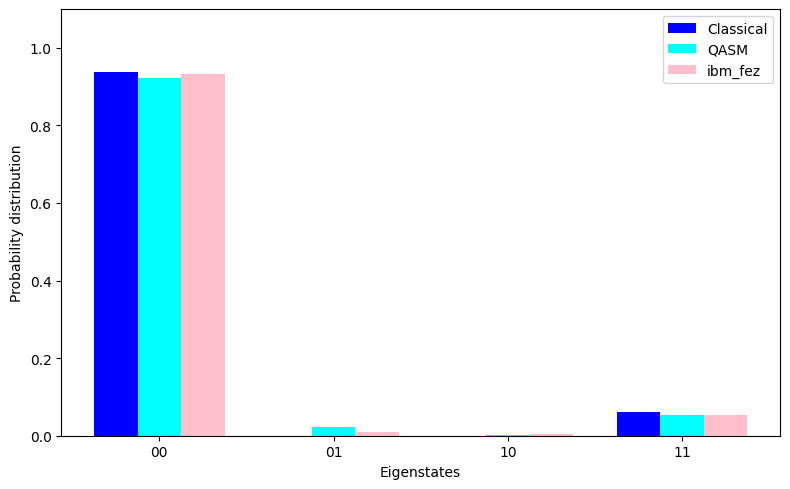

In [ ]:
# Data
classical_result = np.abs(psi_fin)**2  # dari propagasi klasik
eigenstates = ['00', '01', '10', '11']
x = np.arange(len(eigenstates))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width, classical_result, width, label='Classical', color='blue')
ax.bar(x,         qasm_result,      width, label='QASM',      color='cyan')
ax.bar(x + width, real_result,      width, label=f'{backend.name}', color='pink')

ax.set_xlabel('Eigenstates')
ax.set_ylabel('Probability distribution')
ax.set_xticks(x)
ax.set_xticklabels(eigenstates)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## **ENCODING AN ARBITRARY HAMILTONIAN IN THE BASIS OF PAULI MATRICES**

In [ ]:
#pauli matrix decomposition - utility functions
def vec_query(arr, my_dict):
    import numpy as np
    return np.vectorize(my_dict.__getitem__, otypes=[tuple])(arr)

def nested_kronecker_product(a):
    import numpy as np
    if len(a) == 2:
        return np.kron(a[0], a[1])
    else:
        return np.kron(a[0], nested_kronecker_product(a[1:]))
    
def Hilbert_Schmidt(mat1, mat2):
    import numpy as np
    return np.trace(mat1.conj().T*mat2)

In [ ]:
#pauli matrix decomposition
def decompose(Ham_arr, tol=10):
    import numpy as np
    import itertools

    #define a dictionary with the four pauli matrices
    pms = {
        'I': np.array([[1, 0], [0, 1]], dtype=complex), 
        'X': np.array([[0, 1], [1, 0]], dtype=complex), 
        'Y': np.array([[0, -1j], [1j, 0]], dtype=complex), 
        'Z': np.array([[1, 0], [0, -1]], dtype=complex)
    }
    pauli_keys = list(pms.keys())   #keys of the dictionary, i.e. 'I', 'X', 'Y', 'Z'
    nqb = int(np.log2(Ham_arr.shape[0]))  #number of qubits
    output_string = '' #initialize output string

    #make all possible combinations of the pauli matrices for nqb qubits
    sigma_combinations = list(itertools.product(pauli_keys, repeat=nqb))

    #loop through all combinations, calculate the kronecker product, and calculate the coefficient using the Hilbert-Schmidt inner product
    for ii in range(len(sigma_combinations[ii])):
        #take the full pauli string
        pauli_str = ''.join(sigma_combinations[ii])
        # Compute the coefficient for each Pauli string. This is done as follows:
        # 1) Evaluate the tensor product of Pauli String to get a 2^n by 2^n matrix:
        # Turn each element of Pauli String ('ZIXI') into its corresponding
        # 2 by 2 Pauli Matrix, then evaluate the Kronecker product.
        # 2) Compute the Hilbert-Schmidt Inner Product.
        # 3) Normalize by (1/(2^n)).
    norm_factor = 1/(2**nqb)

    #convert the pauli string to list of arrays
    tmp_mat_list = vec_query(np.array(sigma_combinations[ii]), pms)
    
    #evaluate the kronecker product
    tmp_p_matrix = nested_kronecker_product(tmp_mat_list)
    hs_innerprod = Hilbert_Schmidt(tmp_p_matrix, Ham_arr)
    a_coeff = norm_factor * hs_innerprod

    #if the coefficient is non-zero
    if a_coeff != 0.0:
        #assert that cooeficient is less than the tolerance
        min_val = 10**(-tol)
        if abs(a_coeff) < min_val:
            pass
        #if non-zero
        else:
            output_string += str(np.round(a_coeff.real, tol))+"*"+ alt_name
            output_string += '+' # Add a plus sign for the next term!

    return output_string[:-1] # To ignore that extra plus sign


In [ ]:
import qiskit
print(qiskit.__version__)

import numpy
print(numpy.__version__)


2.3.1
2.2.6
